In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

import mne
from mne import io
#from mne.datasets import sample
from mne.minimum_norm import compute_source_psd, read_inverse_operator
from mne.minimum_norm import (make_inverse_operator, apply_inverse,
                              write_inverse_operator)
from mne.io import concatenate_raws

In [2]:
root = ("F:\\PhD\\materials_neuroscience\\EEG_work\\trials\\VAL_KLAUS")
list_file_names = []
for path, dirs, files in os.walk(root):
    for file in files:
        if file.endswith(".bdf"):
             list_file_names.append(os.path.join(root, file))
print(len(list_file_names),'files')
for i in list_file_names:
    print(i[56:])

21 files
aq values deu neg.bdf
ck values deu thr.bdf
dm values deu thr.bdf
dm2 values eng thr.bdf
ds values eng thr.bdf
dz value eng neu.bdf
ER valuess eng thr.bdf
EY values eng neu.bdf
gg valuess deu thr.bdf
gl values deu thr.bdf
kr values deu neg.bdf
ks values deu neg.bdf
LH valuess eng neg.bdf
mc values deu neg.bdf
mm2 values eng neg.bdf
ns values eng neu.bdf
og valuess de neu.bdf
rt values eng neg.bdf
tp values eng neu.bdf
vs values eng neg.bdf
yl values eng thr.bdf


In [3]:
list_raws = []
for item in list_file_names:
    raw = mne.io.read_raw_bdf(item,preload=True)
    #raw = mne.io.read_raw_bdf(item)
    list_raws.append(raw)
    #list_raws.append(raw.pick_types(meg=False, eeg=True, eog=False, exclude='bads'))

for item in list_raws:
    print(item.info['meas_date'])

Extracting EDF parameters from F:\PhD\materials_neuroscience\EEG_work\trials\VAL_KLAUS\aq values deu neg.bdf...
BDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 831487  =      0.000 ...   406.000 secs...
Extracting EDF parameters from F:\PhD\materials_neuroscience\EEG_work\trials\VAL_KLAUS\ck values deu thr.bdf...
BDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 960511  =      0.000 ...   469.000 secs...
Extracting EDF parameters from F:\PhD\materials_neuroscience\EEG_work\trials\VAL_KLAUS\dm values deu thr.bdf...
BDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 710655  =      0.000 ...   347.000 secs...
Extracting EDF parameters from F:\PhD\materials_neuroscience\EEG_work\trials\VAL_KLAUS\dm2 values eng thr.bdf...
BDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 761855  =      0.000 ...   372.000

In [4]:
# Number of samples for each file
for item in list_raws:
    print(len(item.get_data()[0]))

831488
960512
710656
761856
735232
978944
796672
808960
567296
858112
770048
890880
778240
1044480
837632
913408
802816
735232
811008
839680
1015808


In [5]:
raw_obj = concatenate_raws(list_raws)
raw_obj

Measurement date,"January 09, 2002 06:58:59 GMT"
Experimenter,Unknown
Participant,aq
Digitized points,Not available
Good channels,"40 EEG, 1 Stimulus"
Bad channels,None
EOG channels,Not available
ECG channels,Not available
Sampling frequency,2048.00 Hz
Highpass,0.00 Hz
Lowpass,417.00 Hz


In [17]:
#Extract events from raw data
events, event_ids = mne.events_from_annotations(raw_obj, event_id='auto')
event_ids

ValueError: Could not find any of the events you specified.

In [15]:
raw = list_raws[0]
raw.set_eeg_reference()

EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.


Measurement date,"January 09, 2002 06:58:59 GMT"
Experimenter,Unknown
Participant,aq
Digitized points,Not available
Good channels,"40 EEG, 1 Stimulus"
Bad channels,None
EOG channels,Not available
ECG channels,Not available
Sampling frequency,2048.00 Hz
Highpass,0.00 Hz
Lowpass,417.00 Hz


In [21]:
#raw.set_eeg_reference()

# set EEG average reference
events = mne.find_events(raw, stim_channel=raw.info['ch_names'],initial_event=True)
events

246 events found on stim channel Status
Event IDs: [    1     2     4     8     9    10    16    25    32    64    73   128
 65536]


array([[     0,      0,  65536],
       [243090,      0,    128],
       [244814,      0,      1],
       [248189,      0,      2],
       [251087,      0,      4],
       [253507,      0,      8],
       [256590,      0,     64],
       [256643,      0,     10],
       [257837,      0,      1],
       [261211,      0,      2],
       [264109,      0,      4],
       [266354,      0,     16],
       [266632,      0,      8],
       [270352,      0,     16],
       [270416,      0,     10],
       [271916,      0,      1],
       [275291,      0,      2],
       [278188,      0,      4],
       [280302,      0,      8],
       [282001,      0,     64],
       [283438,      0,      1],
       [286813,      0,      2],
       [289710,      0,      4],
       [292233,      0,      8],
       [295059,      0,    128],
       [296903,      0,      1],
       [300278,      0,      2],
       [303176,      0,      4],
       [305289,      0,      8],
       [306052,      0,     16],
       [30

In [22]:
# event trigger and conditions
event_id = dict(aud_r=1)
event_id

{'aud_r': 1}

In [31]:
raw.info['ch_names'];

In [26]:
tmin = -0.2  # start of each epoch (200ms before the trigger)
tmax = 0.5  # end of each epoch (500ms after the trigger)
raw.info['bads'] = ['EXG1', 'EXG2', 'EXG3', 'EXG4', 'EXG5', 'EXG6', 'EXG7', 'EXG8',]
picks = mne.pick_types(raw.info, meg=True, eeg=False, eog=True,
                       exclude='bads')
picks

array([], dtype=int32)

In [27]:
baseline = (None, 0)  # means from the first instant to t = 0
reject = dict(grad=4000e-13, mag=4e-12, eog=150e-6)

In [34]:
epochs = mne.Epochs(raw, events, event_id, tmin, tmax, proj=True, picks=picks,
                    baseline=baseline, reject=reject)
epochs

Not setting metadata
41 matching events found


ValueError: No appropriate channels found for the given picks (array([], dtype=int32))

Using data from preloaded Raw for 41 events and 1435 original time points ...
0 bad epochs dropped
Computing rank from data with rank=None
    Using tolerance 6.4e-11 (2.2e-16 eps * 32 dim * 9e+03  max singular value)
    Estimated rank (eeg): 32
    EEG: rank 32 computed from 32 data channels with 0 projectors
Reducing data rank from 32 -> 32
Estimating covariance using SHRUNK
Done.
Estimating covariance using EMPIRICAL
Done.
Using cross-validation to select the best estimator.
Number of samples used : 16851
log-likelihood on unseen data (descending order):
   shrunk: -105.874
   empirical: -106.012
selecting best estimator: shrunk
[done]
Computing rank from covariance with rank=None
    Using tolerance 3.4e-13 (2.2e-16 eps * 32 dim * 48  max singular value)
    Estimated rank (eeg): 32
    EEG: rank 32 computed from 32 data channels with 0 projectors


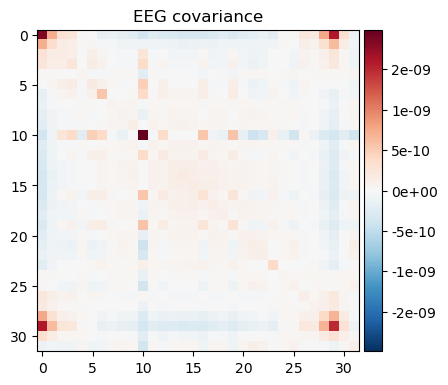

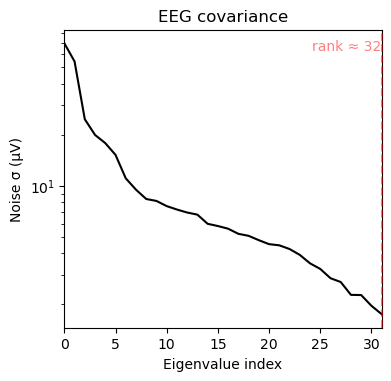

In [35]:
noise_cov = mne.compute_covariance(
    epochs, tmax=0., method=['shrunk', 'empirical'])

fig_cov, fig_spectra = mne.viz.plot_cov(noise_cov, raw.info)

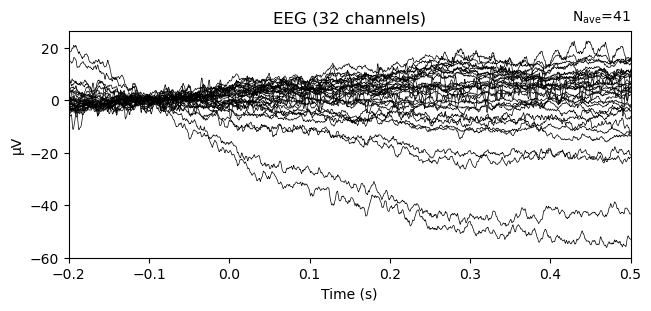

RuntimeError: No digitization points found.

In [36]:
evoked = epochs.average()
evoked.plot()
evoked.plot_topomap(times=np.linspace(0.05, 0.15, 5), ch_type='mag')

# Show whitening
evoked.plot_white(noise_cov)